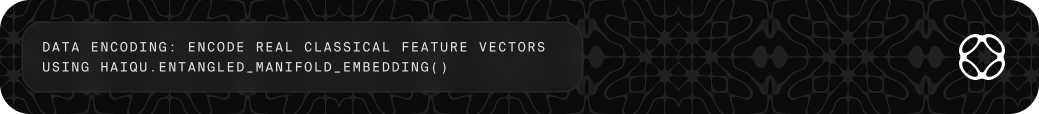

This notebook demonstrates how to use `haiqu.entangled_manifold_embedding()` to encode a vector of real features into a quantum state.

- For 1000 classical features known techniques in the literature would require as many qubits for the encoding, which falls beyond the capabilities of current hardware.
- The same vector can be encoded into a more complex Hilbert space with a proposed technique lowering the amount of needed qubits to 100 and less and controllable by the user.

### `haiqu.entangled_manifold_embedding()`

- **What does it do?** Entangled Manifold Embedding (EME) encodes classical real feature vectors by parametrizing a Hilbert space of controllable entanglement.
- **How do I use it?** Pass a real vector to create a data loading job, then retrieve results with `job.result()`.
- **What are the options?** Optional `density` parameter controls the complexity of the quantum state and amount of features which can be encoded. Additional hyperparameters for circuit synthesis include `num_layers`, `truncation_cutoff` and `fine_tuning_iterations`.
- **Which option do you recommend?** Start with the default settings for basic use cases. Observe how many qubits are used in the process and tune the denisty if necessary.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, create a desired quantum state.

In [1]:
import qiskit
import numpy as np
import pandas as pd
from haiqu.sdk import haiqu
import matplotlib.pyplot as plt
from qiskit.circuit.library import StatePreparation

haiqu.login()
haiqu.init("EME Tutorial")

rng = np.random.default_rng(seed=42)

feature_vector_size = 1000
features = rng.normal(size=feature_vector_size)  # a real vector with 1000 values

densities = [1, 2, 3, 4]

## Run benchmark scenarios

Prepare an encoding into a quantum state with different densities.

In [2]:
qubits = []

for density in densities:
    job = haiqu.entangled_manifold_embedding(features, density=density, fine_tuning_iterations=0)
    qc = job.result()
    qubits.append(qc.num_qubits)

Haiqu's Entangled Manifold Embedding (EME) allows encoding of larger feature vectors for quantum machine learning tasks:

In [3]:
for nq, density in zip(qubits, densities):
    print(f"Encoding of {feature_vector_size} classical features with density {density} requires {nq} qubits.")

Encoding of 1000 classical features with density 1 requires 1000 qubits.
Encoding of 1000 classical features with density 2 requires 252 qubits.
Encoding of 1000 classical features with density 3 requires 114 qubits.
Encoding of 1000 classical features with density 4 requires 66 qubits.


While denstities 1-2 require more qubits than generally available in today's quantum hardware, it is possible to successfully encode 1000 features with a proposed method with density 3 and 4.

> **💡 Good to Know:** EME with density set to 1 naturally produces the angular encoding, which requires as many qubits as there are features and is the most common in quantum machine learning. Proposed technique allows to naturally extend this encoding by parametrizing a more complex Hilbert space.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

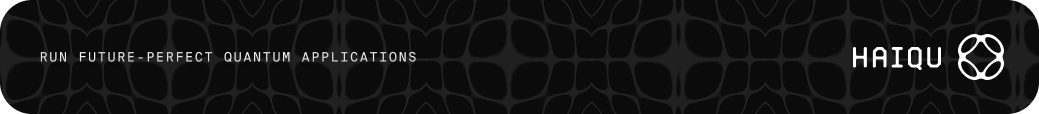